# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

**Student:** Karan Chakradhari  
**College:** Dr. C.V. Raman University

---
## 1. Introduction

For this project I'm working with a dataset of farm records spread across three cropping seasons — **Kharif, Rabi and Zaid** — covering 8 Indian states and 8 major crops. It includes farming practices, weather conditions, production numbers, resource usage and the economics of each farm (cost, revenue, profit).

**Problem Statement:** Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. Raw agricultural data doesn't clearly explain how performance changes across seasons on its own. So the goal here is to dig into the data and pull out the seasonal patterns, trends and relationships that actually explain what's going on.

**What I'm trying to do:** clean up the dataset, compare how the three seasons perform against each other, figure out what actually drives yield and profit, and end up with a few practical takeaways for planning around the season.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 150)

## 2. Load the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 3. Data Cleaning

Before doing anything else, I checked the dataset for missing values and duplicate rows.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [6]:
# Impute missing numeric values with the column median (robust to outliers)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} missing values with median = {median_val:.2f}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Filled Rainfall_mm missing values with median = 582.00
Filled Soil_Moisture_pct missing values with median = 26.40
Filled Yield_Tonnes_Ha missing values with median = 1.74

Remaining missing values: 0


In [7]:
SEASONS = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2C5F2D', 'Rabi': '#6B9E42', 'Zaid': '#D9A441'}
colors = [SEASON_COLORS[s] for s in SEASONS]

print("Season distribution:")
print(df['Season'].value_counts())
print("\nCrop distribution:")
print(df['Crop'].value_counts())
print("\nStates covered:", df['State'].nunique())
print("\nIrrigation methods:")
print(df['Irrigation_Method'].value_counts())

Season distribution:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop distribution:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

States covered: 8

Irrigation methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 4. Seasonal Performance Overview

First question: how do yield, revenue, cost and profit actually compare across the three seasons?

In [8]:
seasonal_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Farms=('Farm_ID', 'count')
).loc[SEASONS].round(2)
seasonal_summary

,Avg_Yield_t_ha,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Farms
Season,,,,,
Kharif,5.63,710719.06,531804.41,178914.65,1779
Rabi,5.04,601526.05,513836.58,87689.47,1627
Zaid,4.64,519171.90,543976.73,-24804.82,594


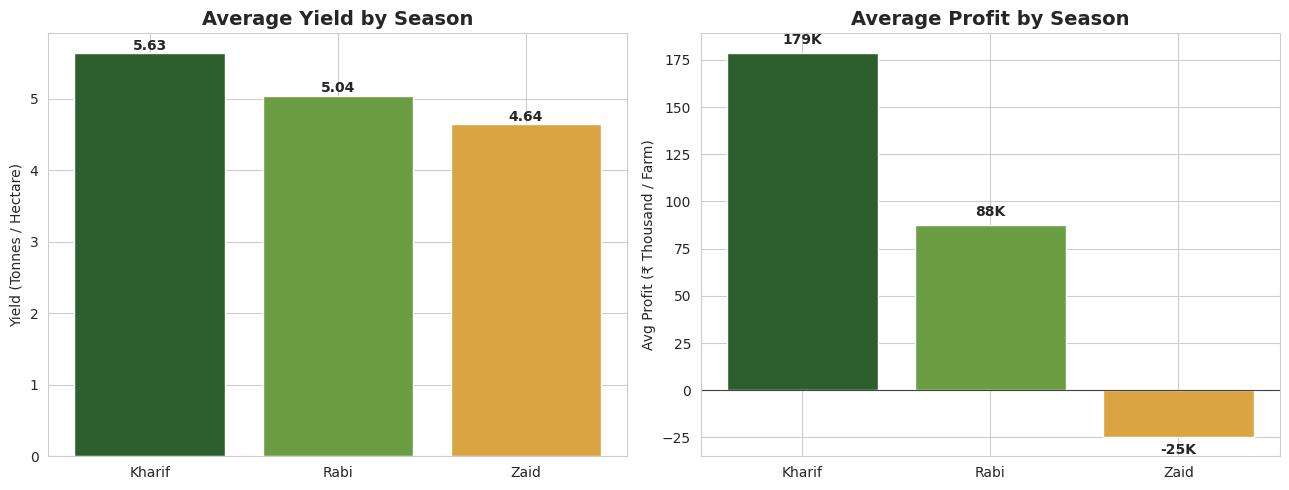

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(SEASONS, seasonal_summary['Avg_Yield_t_ha'], color=colors)
axes[0].set_title('Average Yield by Season', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Yield (Tonnes / Hectare)')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{b.get_height():.2f}", ha='center', fontweight='bold')

bars2 = axes[1].bar(SEASONS, seasonal_summary['Avg_Profit_INR']/1000, color=colors)
axes[1].axhline(0, color='#444444', linewidth=0.8)
axes[1].set_title('Average Profit by Season', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Profit (₹ Thousand / Farm)')
for b in bars2:
    y = b.get_height()
    axes[1].text(b.get_x()+b.get_width()/2, y + (3 if y>=0 else -3), f"{y:.0f}K",
                 ha='center', va='bottom' if y>=0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

**What this shows:** Kharif comes out on top — highest average yield (5.63 t/ha) and the highest average profit (₹1.79 lakh per farm). Zaid is the weak spot; farms there run at a loss on average.

## 5. Environmental Conditions Across Seasons

Rainfall, temperature and humidity are probably the biggest reason the three seasons behave so differently, so I looked at those next.

In [10]:
env_summary = df.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temp_C=('Avg_Temperature_C', 'mean'),
    Avg_Humidity_pct=('Humidity_pct', 'mean'),
    Avg_Soil_Moisture_pct=('Soil_Moisture_pct', 'mean'),
).loc[SEASONS].round(2)
env_summary

,Avg_Rainfall_mm,Avg_Temp_C,Avg_Humidity_pct,Avg_Soil_Moisture_pct
Season,,,,
Kharif,849.20,28.45,71.81,31.15
Rabi,437.62,23.49,57.89,24.07
Zaid,304.65,31.04,52.01,19.28


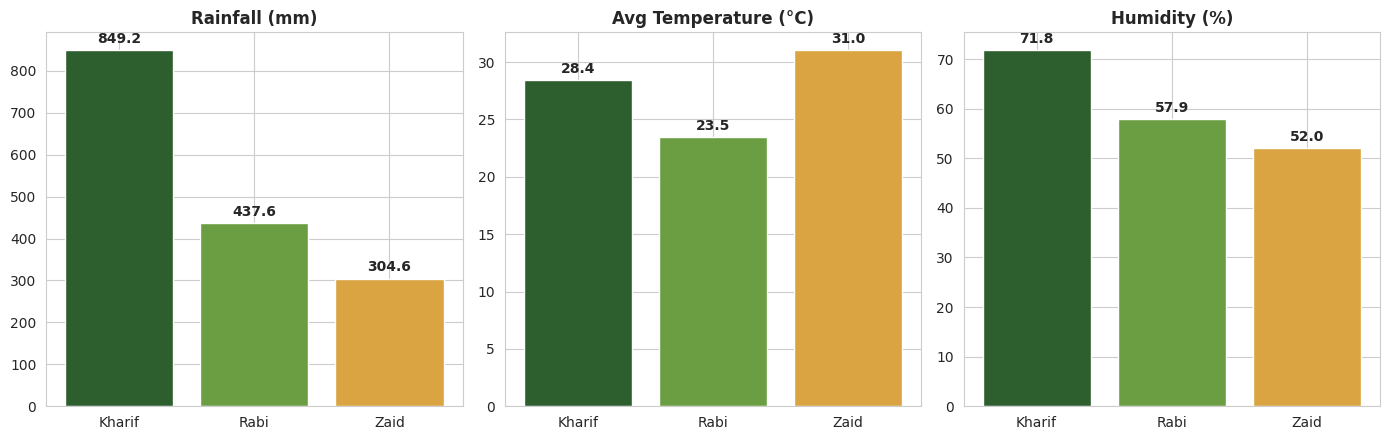

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = [('Avg_Rainfall_mm', 'Rainfall (mm)'), ('Avg_Temp_C', 'Avg Temperature (°C)'), ('Avg_Humidity_pct', 'Humidity (%)')]
for ax, (col, label) in zip(axes, metrics):
    bars = ax.bar(SEASONS, env_summary[col], color=colors)
    ax.set_title(label, fontweight='bold')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+env_summary[col].max()*0.02, f"{b.get_height():.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**What this shows:** Kharif is the monsoon season — it gets the most rainfall (849 mm) and the highest humidity (72%). Zaid, on the other hand, is the hottest (31°C) and driest (305 mm) of the three, which lines up with the lower yields and water stress seen there.

## 6. Water Usage, Irrigation and Disease Risk

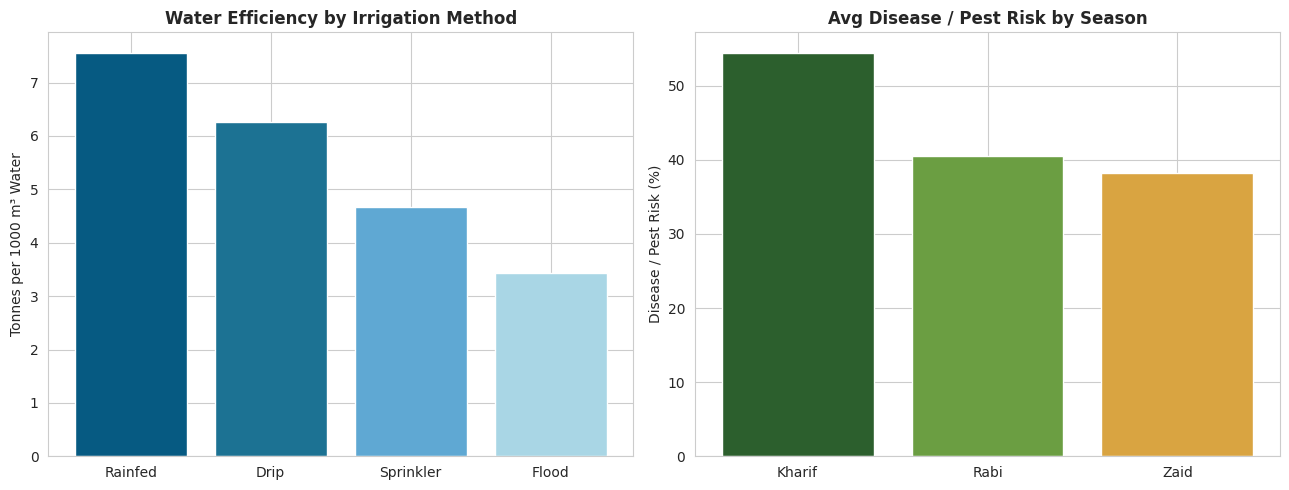

Irrigation_Method
Rainfed      7.56
Drip         6.27
Sprinkler    4.67
Flood        3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


In [12]:
irrigation_summary = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)
disease_summary = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().loc[SEASONS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(irrigation_summary.index, irrigation_summary.values, color=['#065A82','#1C7293','#5FA8D3','#A9D6E5'])
axes[0].set_title('Water Efficiency by Irrigation Method', fontweight='bold')
axes[0].set_ylabel('Tonnes per 1000 m³ Water')

axes[1].bar(SEASONS, disease_summary.values, color=colors)
axes[1].set_title('Avg Disease / Pest Risk by Season', fontweight='bold')
axes[1].set_ylabel('Disease / Pest Risk (%)')

plt.tight_layout()
plt.show()

print(irrigation_summary.round(2))
print()
print(disease_summary.round(2))

**What this shows:** Rainfed and drip irrigation are noticeably more water-efficient than flood irrigation. Disease and pest risk is also highest in Kharif (54.5%) and lowest in Zaid (38.2%) — probably because the humidity in Kharif is more favorable for pests and disease.

## 7. Crop-wise Yield Comparison Across Seasons

In [13]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')[SEASONS].round(2)
crop_season_yield['% Change (Kharif to Zaid)'] = ((crop_season_yield['Zaid'] - crop_season_yield['Kharif']) / crop_season_yield['Kharif'] * 100).round(1)
crop_season_yield.sort_values('% Change (Kharif to Zaid)')

Season,Kharif,Rabi,Zaid,% Change (Kharif to Zaid)
Crop,,,,
Pulses,1.04,0.88,0.67,-35.6
Chilli,1.73,1.47,1.20,-30.6
Cotton,1.37,1.20,0.96,-29.9
Groundnut,1.48,1.23,1.04,-29.7
Rice,2.70,2.32,1.90,-29.6
Sugarcane,53.46,43.29,38.42,-28.1
Maize,2.97,2.60,2.29,-22.9
Wheat,2.25,2.06,1.75,-22.2


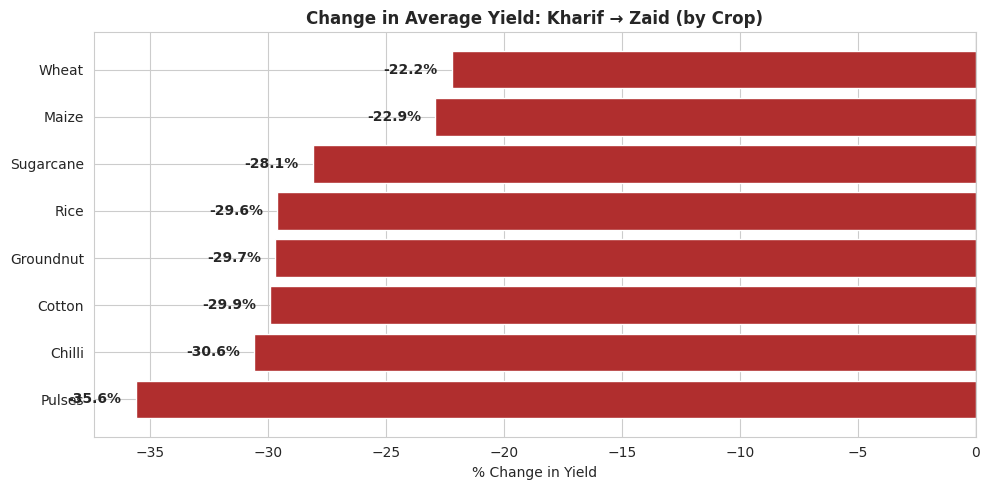

In [14]:
pct_change = crop_season_yield['% Change (Kharif to Zaid)'].sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pct_change.index, pct_change.values, color='#B02E2E')
ax.axvline(0, color='#444444', linewidth=0.8)
ax.set_title('Change in Average Yield: Kharif → Zaid (by Crop)', fontweight='bold')
ax.set_xlabel('% Change in Yield')
for i, v in enumerate(pct_change.values):
    ax.text(v - 0.6, i, f"{v:.1f}%", va='center', ha='right', fontweight='bold')
plt.tight_layout()
plt.show()

**What this shows:** Every single one of the 8 crops yields less in Zaid than in Kharif — the drop ranges from about 22% (wheat, maize) up to 35% (pulses). Since this shows up across every crop and not just one or two, it looks like a genuine seasonal effect rather than something specific to a particular crop.

## 8. Correlation Analysis — What Drives Yield?

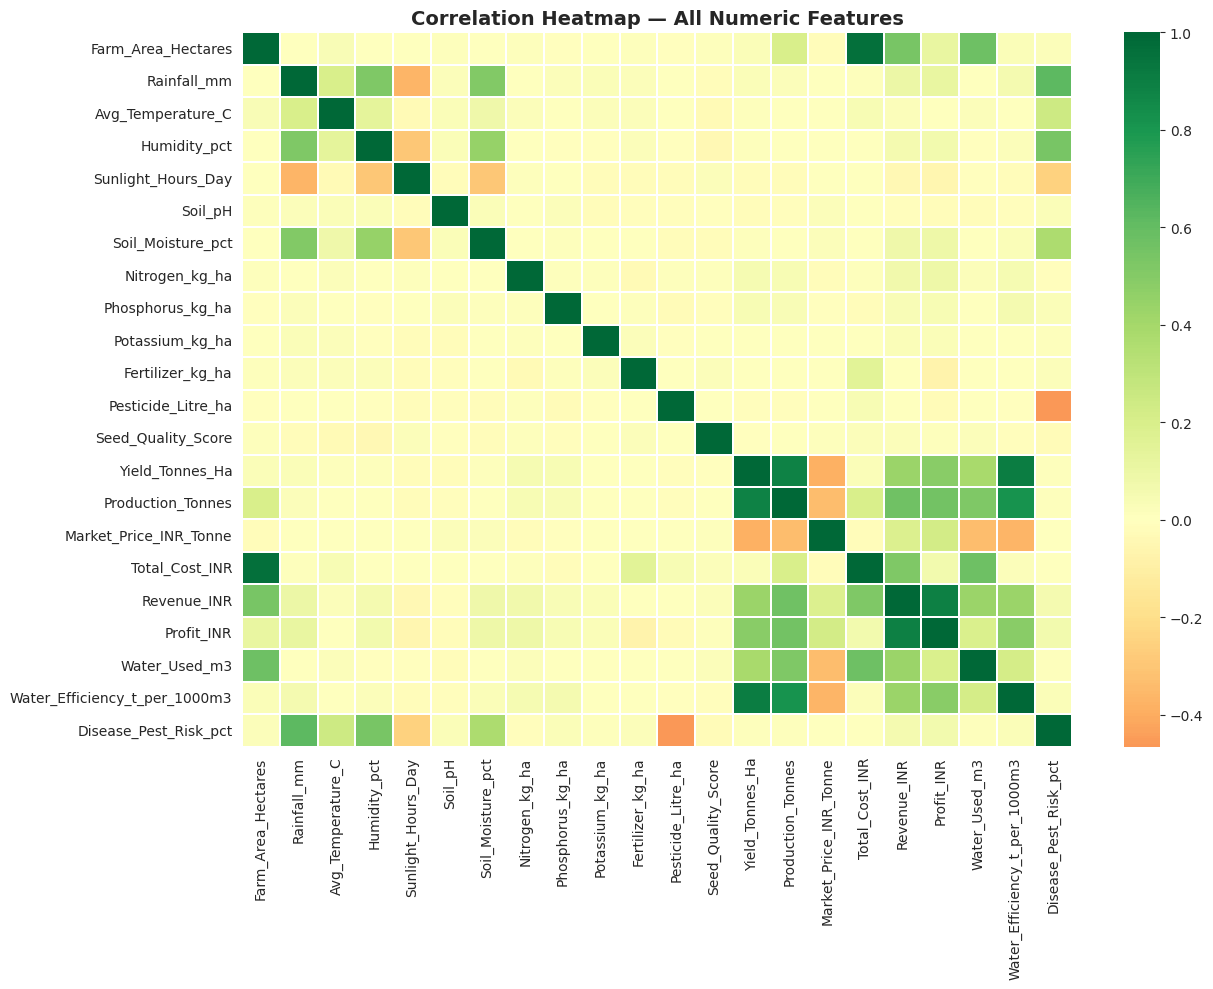

In [15]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap='RdYlGn', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — All Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
print("Features most correlated with Yield_Tonnes_Ha:")
yield_corr.head(8)

Features most correlated with Yield_Tonnes_Ha:


Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Market_Price_INR_Tonne          -0.382607
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Name: Yield_Tonnes_Ha, dtype: float64

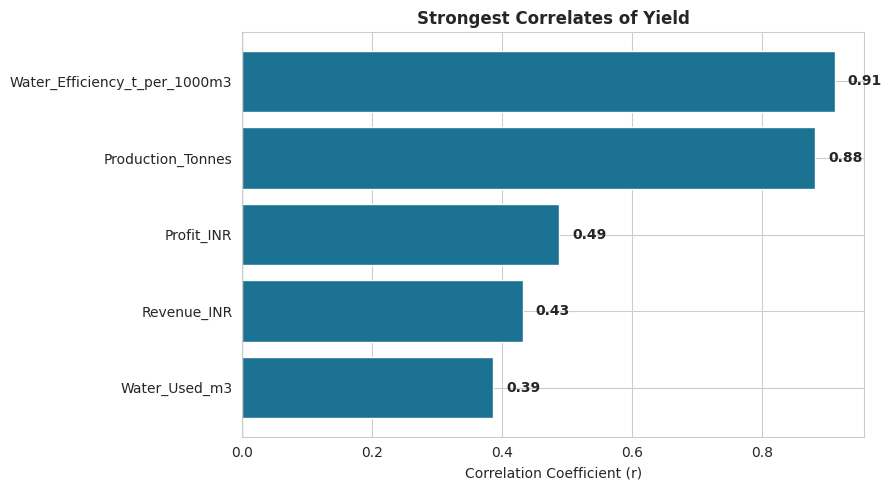

In [17]:
top5 = yield_corr.head(5).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#B02E2E' if v < 0 else '#1C7293' for v in top5.values]
ax.barh(top5.index, top5.values, color=bar_colors)
ax.axvline(0, color='#444444', linewidth=0.8)
ax.set_title('Strongest Correlates of Yield', fontweight='bold')
ax.set_xlabel('Correlation Coefficient (r)')
for i, v in enumerate(top5.values):
    ax.text(v + (0.02 if v>=0 else -0.02), i, f"{v:.2f}", va='center', ha='left' if v>=0 else 'right', fontweight='bold')
plt.tight_layout()
plt.show()

**What this shows:** Water-use efficiency (r = 0.91) and production volume (r = 0.88) are by far the strongest correlates of yield. What surprised me a bit is that fertilizer, pesticide and rainfall on their own don't correlate nearly as strongly — it seems like *how efficiently* water is used matters more than how much of anything is applied.

## 9. Economic Risk — Loss-Making Farms by Season

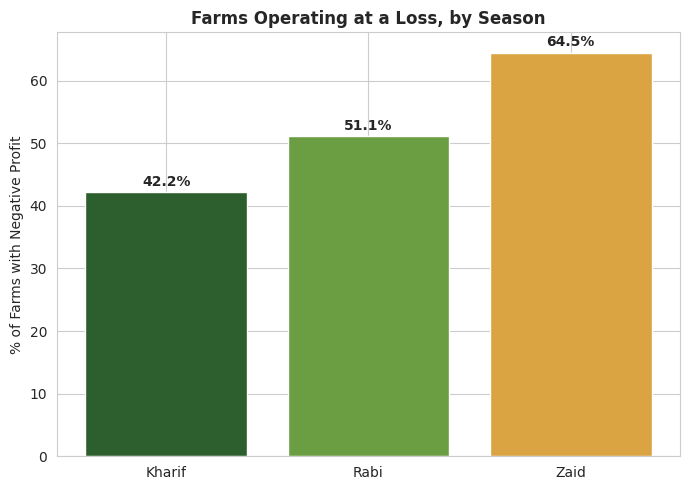

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64

In [18]:
loss_pct = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean() * 100).loc[SEASONS]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(SEASONS, loss_pct.values, color=colors)
ax.set_title('Farms Operating at a Loss, by Season', fontweight='bold')
ax.set_ylabel('% of Farms with Negative Profit')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

loss_pct.round(1)

**What this shows:** The share of farms running at a loss climbs steadily across the seasons — 42% in Kharif, 51% in Rabi, and 65% in Zaid. So Zaid isn't just the lowest-yielding season, it's also clearly the riskiest one financially.

## 10. State-wise Performance

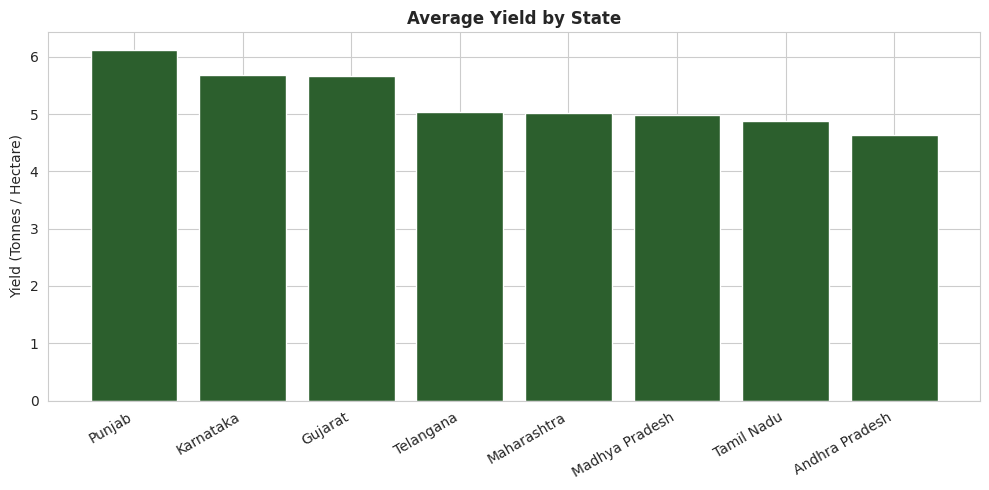

State
Punjab            6.12
Karnataka         5.69
Gujarat           5.66
Telangana         5.04
Maharashtra       5.02
Madhya Pradesh    4.99
Tamil Nadu        4.88
Andhra Pradesh    4.63
Name: Yield_Tonnes_Ha, dtype: float64

In [19]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(state_yield.index, state_yield.values, color='#2C5F2D')
ax.set_title('Average Yield by State', fontweight='bold')
ax.set_ylabel('Yield (Tonnes / Hectare)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

state_yield.round(2)

## 11. Key Insights

1. **Kharif is the strongest season overall** — best yield (5.63 t/ha) and best average profit (₹1.79L/farm), thanks largely to the monsoon rainfall and humidity.
2. **Zaid is the riskiest season** — lowest yield, an average net loss per farm, and the highest share of loss-making farms (65%).
3. **Every crop does worse in Zaid than in Kharif** (down 22%–35%), so this really is a season-wide pattern and not just a couple of crops struggling.
4. **Water-use efficiency is the single biggest driver of yield** (r = 0.91) — more so than fertilizer, pesticide or rainfall on their own.
5. **The irrigation method makes a real difference** — rainfed and drip irrigation are far more water-efficient than flood irrigation.
6. **Disease/pest risk is highest in the humid Kharif season** and lowest in dry Zaid, which is an interesting trade-off between productivity and crop health risk.
7. **Punjab, Karnataka and Gujarat** came out with the highest average yields among the states in this dataset.

## 12. Recommendations

- **Push for water-efficient irrigation (drip/rainfed) over flood irrigation**, especially during Zaid, since that's when water stress hurts the most.
- **Treat Zaid as a higher-risk season for planning** — with 65% of farms losing money, farmers and lenders should factor that risk in before committing inputs or credit.
- **Focus more on water-use efficiency than on increasing fertilizer or pesticide use**, since efficiency is what actually correlates with better yield here.
- **Step up pest and disease management specifically during Kharif**, when the risk is clearly at its highest.
- **Look at what high-yield states like Punjab, Karnataka and Gujarat are doing differently**, and see if those practices can be applied elsewhere.

---
*Analysis done in Python (Pandas, NumPy, Matplotlib, Seaborn) as part of the VOIS AICTE Batch1 2026-2027 Major Project — Seasonal Agriculture Performance Analysis.*